### Available Tools for Attacks against Synthetic Data (IBM)

In [ ]:
from apt.risk.data_assessment.dataset_assessment_manager import DatasetAssessmentManager, DatasetAssessmentManagerConfig
from apt.utils.datasets import ArrayDataset
import pandas as pd

In [20]:
dataset_assessment_manager = DatasetAssessmentManager(
    DatasetAssessmentManagerConfig(persist_reports=True, generate_plots=True))

In [21]:
train_data=pd.read_csv('data/adult_complete.csv')
test_data=pd.read_csv('data/adult_test.csv')
synthetic_data=pd.read_csv('data/synthetic_data.csv')

In [22]:
categorical_columns = ['workclass','education-num','marital-status','occupation','relationship','race','sex','native-country','income']
numerical_columns = ['age','capital-gain','capital-loss']

In [23]:
# Preprocessing Scaling and Encoded
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

num_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

# Preprocess categorical columns
cat_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore',sparse_output=False,drop='if_binary'))
])

# Build transformer with preprocessing pipelines.
preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", num_transformer, numerical_columns),
        ("categorical", cat_transformer, categorical_columns),
    ]
)   

preprocessor.fit(train_data)
columns_preprocessor=preprocessor.get_feature_names_out()

train_data_preprocess=pd.DataFrame(preprocessor.transform(train_data),columns=columns_preprocessor)
test_data_preprocess=pd.DataFrame(preprocessor.transform(test_data),columns=columns_preprocessor)
synthetic_data_preprocess=pd.DataFrame(preprocessor.transform(synthetic_data),columns=columns_preprocessor)


In [24]:
columns_wto_target=train_data_preprocess.columns[0:len(train_data_preprocess.columns)-1]
target='categorical__income_>50K'

In [25]:
x_train, y_train = train_data_preprocess[columns_wto_target].values, train_data_preprocess[target].values
x_test, y_test = test_data_preprocess[columns_wto_target].values, test_data_preprocess[target].values
x_synth, y_synth = synthetic_data_preprocess[columns_wto_target].values, synthetic_data_preprocess[target].values

In [26]:
synthetic_data = ArrayDataset(x_synth, y_synth)
original_data_members = ArrayDataset(x_train, y_train)
original_data_non_members = ArrayDataset(x_test, y_test)

Running MembershipKnnProbabilities attack on adult_dataset
0: KS = 0.0148 (p-value = 1.532e-03, are equal = False)
Distributions differ in column 0, p-value: 0.0015315873033458212
1: KS = 0.9167 (p-value = 0.000e+00, are equal = False)
Distributions differ in column 1, p-value: 0.0
2: KS = 0.9515 (p-value = 0.000e+00, are equal = False)
Distributions differ in column 2, p-value: 0.0
3: KS = 0.0030 (p-value = 9.981e-01, are equal = True)
Accept H0, similar distributions in column 3
4: KS = 0.0003 (p-value = 1.000e+00, are equal = True)
Accept H0, similar distributions in column 4
5: KS = 0.0023 (p-value = 1.000e+00, are equal = True)
Accept H0, similar distributions in column 5
6: KS = 0.0001 (p-value = 1.000e+00, are equal = True)
Accept H0, similar distributions in column 6
7: KS = 0.0058 (p-value = 6.342e-01, are equal = True)
Accept H0, similar distributions in column 7
8: KS = 0.0025 (p-value = 1.000e+00, are equal = True)
Accept H0, similar distributions in column 8
9: KS = 0.0019

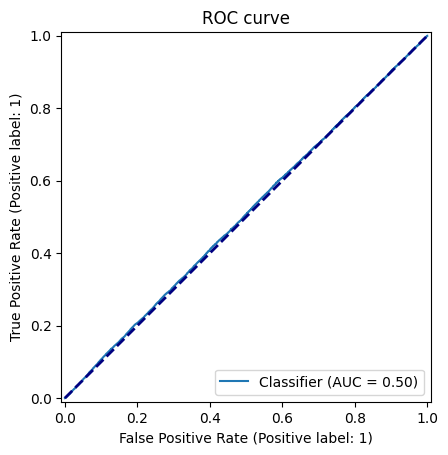

In [27]:
dataset_name = 'adult_dataset'
scores = dataset_assessment_manager.assess(
    original_data_members, original_data_non_members, synthetic_data, dataset_name)
dataset_assessment_manager.dump_all_scores_to_files()